In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from sklearn.cluster import KMeans

%matplotlib inline

## Loading the training data

Two training sets: one with repeated gestures (same gesture done multiple times in one recording) and one with single gestures. Let me load them up and see what we're working with.

In [2]:
# paths
repeated_dir = 'data/Repeated_gesture'
single_dir = 'data/Single_gesture'

# figure out which files belong to which gesture
# the naming is kinda inconsistent lol
gesture_prefixes = {
    'wave': 'wave',
    'inf': 'inf',       # infinity
    'eight': 'eight',
    'circle': 'circle',
    'beat3': 'beat3',
    'beat4': 'beat4'
}

def load_imu(fpath):
    raw = np.loadtxt(fpath)
    # columns: ts, Wx, Wy, Wz, Ax, Ay, Az
    # drop timestamp, keep 6D IMU
    return raw[:, 1:]

# load repeated gesture files
repeated_data = {}
for gname, prefix in gesture_prefixes.items():
    files = sorted(glob.glob(os.path.join(repeated_dir, prefix + '*.txt')))
    repeated_data[gname] = [load_imu(f) for f in files]
    print(f"{gname}: {len(files)} files, shapes: {[d.shape for d in repeated_data[gname]]}")

print()

# load single gesture files  
single_data = {}
for gname, prefix in gesture_prefixes.items():
    files = sorted(glob.glob(os.path.join(single_dir, prefix + '*.txt')))
    single_data[gname] = [load_imu(f) for f in files]
    print(f"{gname}: {len(files)} files, shapes: {[d.shape for d in single_data[gname]]}")

wave: 5 files, shapes: [(2266, 6), (2526, 6), (3225, 6), (3070, 6), (3443, 6)]
inf: 5 files, shapes: [(1983, 6), (3379, 6), (2495, 6), (2125, 6), (2435, 6)]
eight: 5 files, shapes: [(2391, 6), (3148, 6), (3371, 6), (2633, 6), (2758, 6)]
circle: 5 files, shapes: [(1944, 6), (2354, 6), (2133, 6), (2295, 6), (1901, 6)]
beat3: 5 files, shapes: [(2220, 6), (2608, 6), (2643, 6), (2865, 6), (3095, 6)]
beat4: 5 files, shapes: [(3017, 6), (3088, 6), (2307, 6), (2613, 6), (3009, 6)]

wave: 1 files, shapes: [(441, 6)]
inf: 1 files, shapes: [(852, 6)]
eight: 1 files, shapes: [(596, 6)]
circle: 1 files, shapes: [(628, 6)]
beat3: 1 files, shapes: [(749, 6)]
beat4: 1 files, shapes: [(845, 6)]


## Let me visualize what the data looks like

I want to see the raw IMU signals for each gesture to understand the patterns. Plotting one repeated file per gesture.

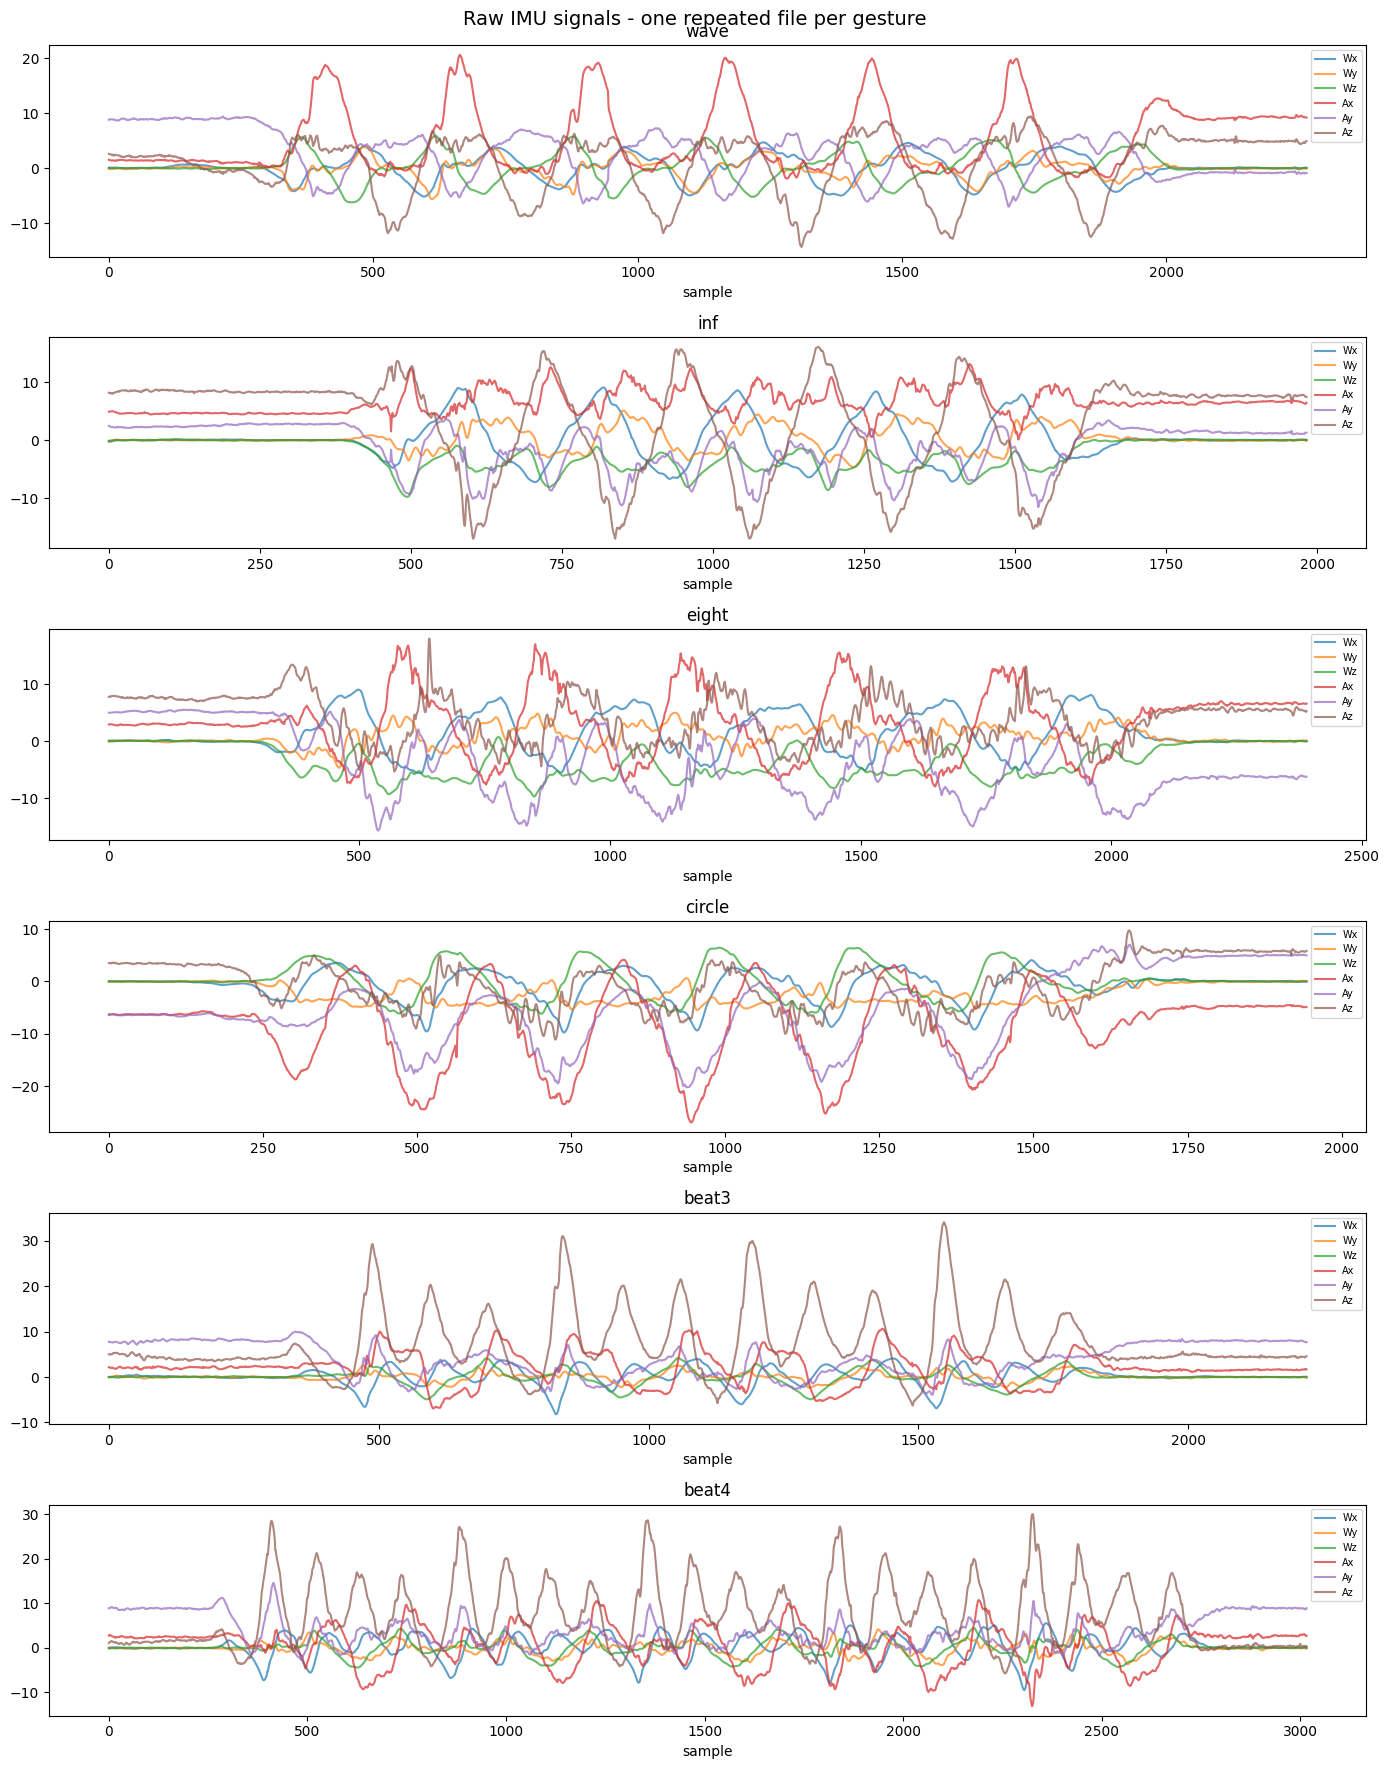

In [3]:
channel_names = ['Wx', 'Wy', 'Wz', 'Ax', 'Ay', 'Az']

fig, axes = plt.subplots(6, 1, figsize=(14, 18))
fig.suptitle('Raw IMU signals - one repeated file per gesture', fontsize=14)

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown']

for idx, (gname, dlist) in enumerate(repeated_data.items()):
    ax = axes[idx]
    dat = dlist[0]  # just look at the first file
    for ch in range(6):
        ax.plot(dat[:, ch], alpha=0.7, label=channel_names[ch])
    ax.set_title(gname)
    ax.legend(loc='upper right', fontsize=7)
    ax.set_xlabel('sample')

plt.tight_layout()
plt.show()

## Splitting repeated gestures into individual ones

The repeated gesture files contain the same gesture done multiple times. I need to split them into individual gestures. Let me look at the signal energy to find the "rest" periods between repetitions.

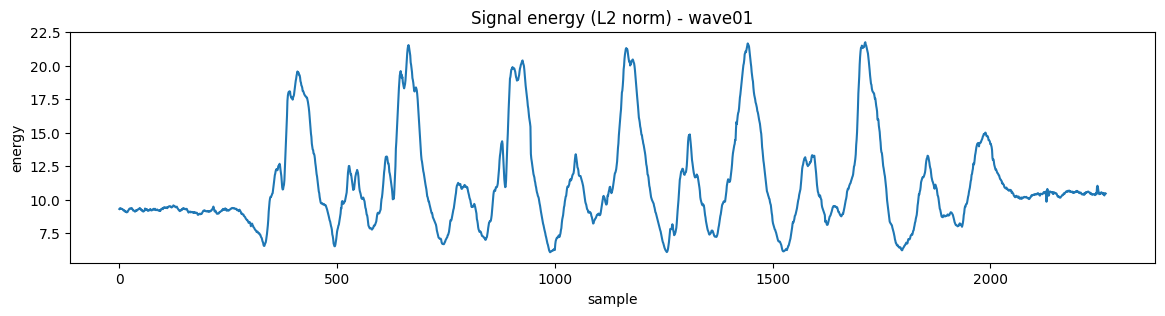

energy stats: min=6.085, max=21.741, mean=11.156


In [4]:
# first let me look at what the energy looks like for a wave file
test_dat = repeated_data['wave'][0]
energy = np.sqrt(np.sum(test_dat**2, axis=1))

plt.figure(figsize=(14, 3))
plt.plot(energy)
plt.title('Signal energy (L2 norm) - wave01')
plt.xlabel('sample')
plt.ylabel('energy')
plt.show()
print("energy stats: min={:.3f}, max={:.3f}, mean={:.3f}".format(energy.min(), energy.max(), energy.mean()))

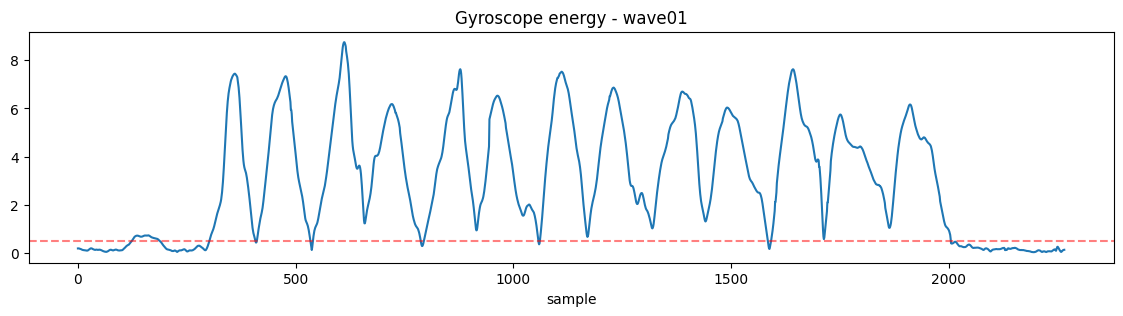

gyro energy stats: 0.023961734390481836 8.754146785229615 3.0421260046705427


In [5]:
# ok so the energy doesn't really go to zero between repetitions
# because of gravity component in accelerometer (always ~9.8)
# let me try looking at just the gyroscope channels which should be near zero when not moving

gyro_energy = np.sqrt(np.sum(test_dat[:, :3]**2, axis=1))

plt.figure(figsize=(14, 3))
plt.plot(gyro_energy)
plt.title('Gyroscope energy - wave01')
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5)
plt.xlabel('sample')
plt.show()
print("gyro energy stats:", gyro_energy.min(), gyro_energy.max(), gyro_energy.mean())

In [6]:
def segment_gesture(imu_data, threshold=0.3, min_gesture_len=50, min_gap=30):
    """
    split a repeated gesture recording into individual gestures
    using gyroscope energy to find rest periods
    """
    gyro = imu_data[:, :3]
    energy = np.sqrt(np.sum(gyro**2, axis=1))
    
    # smooth it a bit
    kernel_size = 15
    kernel = np.ones(kernel_size) / kernel_size
    smooth_energy = np.convolve(energy, kernel, mode='same')
    
    # find active regions (above threshold)
    active = smooth_energy > threshold
    
    # find transitions
    segments = []
    in_gesture = False
    start = 0
    
    for i in range(len(active)):
        if active[i] and not in_gesture:
            start = i
            in_gesture = True
        elif not active[i] and in_gesture:
            if i - start >= min_gesture_len:
                segments.append((start, i))
            in_gesture = False
    
    # don't forget the last one if it ends while active
    if in_gesture and len(active) - start >= min_gesture_len:
        segments.append((start, len(active)))
    
    # merge segments that are too close together
    merged = []
    for seg in segments:
        if merged and seg[0] - merged[-1][1] < min_gap:
            merged[-1] = (merged[-1][0], seg[1])
        else:
            merged.append(seg)
    
    return [imu_data[s:e] for s, e in merged], merged

# test on wave01
segs, boundaries = segment_gesture(test_dat)
print(f"found {len(segs)} segments")
print("segment lengths:", [len(s) for s in segs])
print("boundaries:", boundaries)

found 2 segments
segment lengths: [83, 1727]
boundaries: [(114, 197), (298, 2025)]


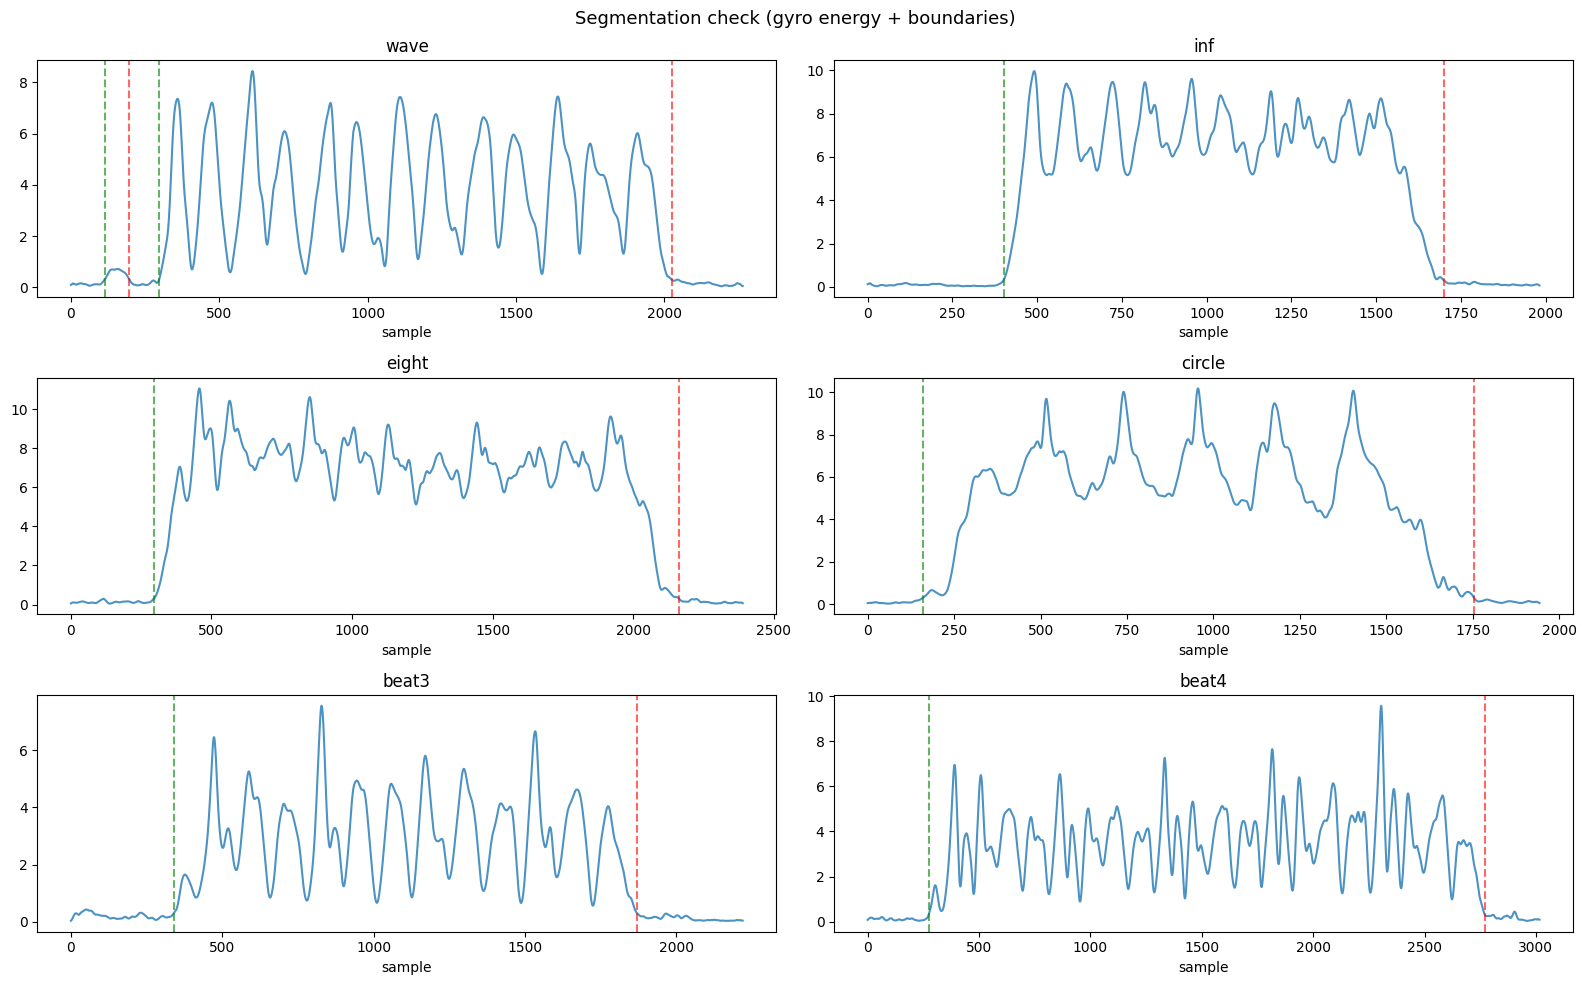

In [7]:
# visualize the segmentation for a few gestures
fig, axes = plt.subplots(3, 2, figsize=(16, 10))
fig.suptitle('Segmentation check (gyro energy + boundaries)', fontsize=13)

for idx, gname in enumerate(gesture_prefixes.keys()):
    ax = axes[idx // 2][idx % 2]
    dat = repeated_data[gname][0]
    gyro_e = np.sqrt(np.sum(dat[:, :3]**2, axis=1))
    
    # smooth for display
    k = np.ones(15) / 15
    smooth = np.convolve(gyro_e, k, mode='same')
    
    ax.plot(smooth, alpha=0.8)
    ax.set_title(gname)
    
    _, bounds = segment_gesture(dat)
    for s, e in bounds:
        ax.axvline(x=s, color='g', linestyle='--', alpha=0.6)
        ax.axvline(x=e, color='r', linestyle='--', alpha=0.6)
    
    ax.set_xlabel('sample')

plt.tight_layout()
plt.show()

In [8]:
# hmm so the segmentation basically gives one big chunk per file...
# the gestures are done continuously without clear rest periods between reps
# each "segment" is like 1500-3000 samples but a single gesture is ~400-800 samples
# so the repeated files have maybe 3-6 reps but my method can't split them

# apply to all files to confirm
for gname in gesture_prefixes.keys():
    total_segs = 0
    for dat in repeated_data[gname]:
        segs, _ = segment_gesture(dat)
        total_segs += len(segs)
    avg_single_len = np.mean([len(s) for s in single_data[gname]])
    print(f"{gname}: {total_segs} segments from 5 files (expected ~{5 * repeated_data[gname][0].shape[0] / avg_single_len:.0f}+ individual gestures)")

wave: 6 segments from 5 files (expected ~26+ individual gestures)
inf: 5 segments from 5 files (expected ~12+ individual gestures)
eight: 6 segments from 5 files (expected ~20+ individual gestures)
circle: 6 segments from 5 files (expected ~15+ individual gestures)
beat3: 5 segments from 5 files (expected ~15+ individual gestures)
beat4: 5 segments from 5 files (expected ~18+ individual gestures)


## Plan B: don't split, use cyclic LR-HMM

OK so splitting the repeated gestures is not really working - the person just keeps moving without pausing between reps. The project PDF says I can use a left-to-right HMM that allows going from the last state back to the first state if I haven't split the repeated data. I think that's the way to go.

So my training data will be:
- Repeated gesture files: each file = one long sequence with the gesture repeated ~3-6 times
- Single gesture files: each file = one short sequence with one gesture

The HMM will need a cyclic left-to-right structure (last state can transition back to first state).

In [9]:
# just use each file as one training sequence - no splitting
training_raw = {}
for gname in gesture_prefixes.keys():
    training_raw[gname] = repeated_data[gname] + single_data[gname]
    lens = [len(s) for s in training_raw[gname]]
    print(f"{gname}: {len(training_raw[gname])} sequences, lengths: {lens}")

wave: 6 sequences, lengths: [2266, 2526, 3225, 3070, 3443, 441]
inf: 6 sequences, lengths: [1983, 3379, 2495, 2125, 2435, 852]
eight: 6 sequences, lengths: [2391, 3148, 3371, 2633, 2758, 596]
circle: 6 sequences, lengths: [1944, 2354, 2133, 2295, 1901, 628]
beat3: 6 sequences, lengths: [2220, 2608, 2643, 2865, 3095, 749]
beat4: 6 sequences, lengths: [3017, 3088, 2307, 2613, 3009, 845]


## Vector Quantization with K-means

I need to discretize the continuous 6D IMU vectors into discrete observation labels for the HMM. Using k-means clustering. The paper recommends 50-100 clusters, let me try 70 first.

In [10]:
# stack all training data together for k-means
all_vectors = []
for gname, seq_list in training_raw.items():
    for seq in seq_list:
        all_vectors.append(seq)

all_imu = np.vstack(all_vectors)
print("total training vectors:", all_imu.shape)
print("value ranges per channel:")
for i, ch in enumerate(channel_names):
    print(f"  {ch}: [{all_imu[:, i].min():.3f}, {all_imu[:, i].max():.3f}]")

total training vectors: (83451, 6)
value ranges per channel:
  Wx: [-10.175, 11.470]
  Wy: [-8.033, 7.445]
  Wz: [-10.372, 6.965]
  Ax: [-26.893, 22.417]
  Ay: [-24.141, 20.326]
  Az: [-17.829, 36.089]


fitting kmeans with 70 clusters...


done! inertia: 915895.8301382612
cluster sizes: min=272, max=4899, mean=1192.2
empty clusters: 0


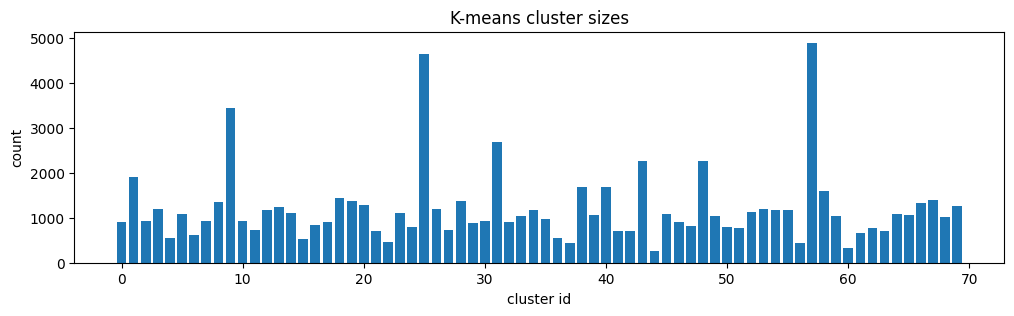

In [11]:
M = 70  # number of observation clusters
print(f"fitting kmeans with {M} clusters...")
kmeans = KMeans(n_clusters=M, random_state=42, n_init=10, max_iter=300)
kmeans.fit(all_imu)
print("done! inertia:", kmeans.inertia_)

# check cluster sizes - don't want empty clusters
labels_all = kmeans.labels_
cluster_sizes = np.bincount(labels_all, minlength=M)
print(f"cluster sizes: min={cluster_sizes.min()}, max={cluster_sizes.max()}, mean={cluster_sizes.mean():.1f}")
print(f"empty clusters: {np.sum(cluster_sizes == 0)}")

plt.figure(figsize=(12, 3))
plt.bar(range(M), cluster_sizes)
plt.title('K-means cluster sizes')
plt.xlabel('cluster id')
plt.ylabel('count')
plt.show()

In [12]:
# quantize all training sequences
def quantize(seq, km):
    return km.predict(seq)

training_obs = {}  # gesture -> list of 1D int arrays
for gname, seq_list in training_raw.items():
    training_obs[gname] = [quantize(s, kmeans) for s in seq_list]
    print(f"{gname}: {len(training_obs[gname])} sequences")
    # sanity check
    print(f"  first seq labels: {training_obs[gname][0][:15]}")
    print(f"  seq lengths: {[len(s) for s in training_obs[gname]]}")

wave: 6 sequences
  first seq labels: [9 9 9 9 9 9 9 9 9 9 9 9 9 9 9]
  seq lengths: [2266, 2526, 3225, 3070, 3443, 441]
inf: 6 sequences
  first seq labels: [31 31 31 31 31 31 31 31 31 31 31 31 31 31 31]
  seq lengths: [1983, 3379, 2495, 2125, 2435, 852]
eight: 6 sequences
  first seq labels: [38 38 38 38 38 38 38 38 38 38 38 38 38 38 38]
  seq lengths: [2391, 3148, 3371, 2633, 2758, 596]
circle: 6 sequences
  first seq labels: [45 45 45 45 45 45 45 45 45 45 45 45 45 45 45]
  seq lengths: [1944, 2354, 2133, 2295, 1901, 628]
beat3: 6 sequences
  first seq labels: [57 57 57 57 57 57 57 57 57 57 57 57 57 57 57]
  seq lengths: [2220, 2608, 2643, 2865, 3095, 749]
beat4: 6 sequences
  first seq labels: [9 9 9 9 9 9 9 9 9 9 9 9 9 9 9]
  seq lengths: [3017, 3088, 2307, 2613, 3009, 845]


In [13]:
import pickle

os.makedirs('models', exist_ok=True)

# save kmeans model
with open('models/kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)
print("saved kmeans model")

# save quantized training data
with open('models/training_obs.pkl', 'wb') as f:
    pickle.dump(training_obs, f)
print("saved training observations")

# also save the raw training sequences in case I need them later
with open('models/training_raw.pkl', 'wb') as f:
    pickle.dump(training_raw, f)
print("saved raw training data")

print(f"\nM = {M} clusters, total {sum(len(v) for v in training_obs.values())} training sequences")

saved kmeans model
saved training observations
saved raw training data

M = 70 clusters, total 36 training sequences


## HMM Implementation

Time to build the actual HMM. Following Rabiner's paper mostly - the forward/backward algorithms and Baum-Welch for training. I'll use scaling to avoid numerical underflow (section V of the paper).

The plan is:
1. Build an HMM class with forward, backward, and training
2. Test it on some toy data first to make sure it works
3. Then train on the real gesture data

In [14]:
class HMM:
    def __init__(self, n_states, n_obs, topology='left-right-cyclic'):
        self.N = n_states
        self.M = n_obs
        self.topology = topology
        
        if topology == 'ergodic':
            self.pi = np.ones(self.N) / self.N
            self.A = np.random.dirichlet(np.ones(self.N), size=self.N)
        else:
            # left-right cyclic: start in state 0, can go forward or loop back
            self.pi = np.zeros(self.N)
            self.pi[0] = 1.0
            self.A = np.zeros((self.N, self.N))
            for i in range(self.N):
                stay = 0.5 + np.random.uniform(0, 0.2)
                self.A[i, i] = stay
                nxt = (i + 1) % self.N  # cyclic: last state -> first state
                self.A[i, nxt] = 1.0 - stay
        
        # B: random emission probs
        self.B = np.random.dirichlet(np.ones(self.M), size=self.N)
        self.B += 1e-8
        self.B /= self.B.sum(axis=1, keepdims=True)
        
        # mask for A structure - enforce during training
        self.A_mask = (self.A > 0).astype(float)
    
    def forward(self, obs):
        # scaled forward (rabiner section V)
        T = len(obs)
        alpha = np.zeros((self.N, T))
        c = np.zeros(T)
        
        alpha[:, 0] = self.pi * self.B[:, obs[0]]
        c[0] = alpha[:, 0].sum() + 1e-300
        alpha[:, 0] /= c[0]
        
        for t in range(1, T):
            alpha[:, t] = (self.A.T @ alpha[:, t-1]) * self.B[:, obs[t]]
            c[t] = alpha[:, t].sum() + 1e-300
            alpha[:, t] /= c[t]
        return alpha, c
    
    def backward(self, obs, c):
        T = len(obs)
        beta = np.zeros((self.N, T))
        beta[:, T-1] = 1.0 / c[T-1]
        for t in range(T-2, -1, -1):
            beta[:, t] = self.A @ (self.B[:, obs[t+1]] * beta[:, t+1])
            beta[:, t] /= c[t]
        return beta
    
    def log_likelihood(self, obs):
        _, c = self.forward(obs)
        return np.sum(np.log(c))
    
    def train(self, obs_sequences, max_iter=100, tol=1e-4, verbose=True):
        ll_history = []
        
        for epoch in range(max_iter):
            all_gamma = []
            all_xi = []
            total_ll = 0
            
            # E-step
            for obs in obs_sequences:
                alpha, c = self.forward(obs)
                beta = self.backward(obs, c)
                T = len(obs)
                
                # gamma
                gamma = alpha * beta
                gamma /= gamma.sum(axis=0, keepdims=True) + 1e-300
                
                # xi - vectorized
                # old triple loop version was way too slow:
                # for t in range(T-1):
                #     for i in range(N):
                #         for j in range(N):
                #             xi[i,j,t] = alpha[i,t]*A[i,j]*B[j,obs[t+1]]*beta[j,t+1]
                xi = np.zeros((self.N, self.N, T-1))
                for t in range(T-1):
                    bj_beta = self.B[:, obs[t+1]] * beta[:, t+1]
                    xi[:, :, t] = alpha[:, t:t+1] * self.A * bj_beta[np.newaxis, :]
                    xi[:, :, t] /= xi[:, :, t].sum() + 1e-300
                
                all_gamma.append(gamma)
                all_xi.append(xi)
                total_ll += np.sum(np.log(c))
            
            ll_history.append(total_ll)
            
            if epoch > 0:
                ll_change = total_ll - ll_history[-2]
                if verbose and epoch % 5 == 0:
                    print(f"  epoch {epoch}: LL = {total_ll:.2f} (change: {ll_change:.4f})")
                if ll_change < -0.01:
                    print(f"  WARNING: LL decreased at epoch {epoch}!")
                if abs(ll_change) < tol:
                    if verbose:
                        print(f"  converged at epoch {epoch}, LL = {total_ll:.2f}")
                    break
            elif verbose:
                print(f"  epoch 0: LL = {total_ll:.2f}")
            
            # M-step: update A
            xi_sum = np.zeros((self.N, self.N))
            gamma_denom_A = np.zeros(self.N)
            for gamma, xi in zip(all_gamma, all_xi):
                xi_sum += xi.sum(axis=2)
                gamma_denom_A += gamma[:, :-1].sum(axis=1)
            gamma_denom_A[gamma_denom_A == 0] = 1e-300
            
            A_new = xi_sum / gamma_denom_A[:, np.newaxis]
            A_new *= self.A_mask  # enforce structure
            A_new /= A_new.sum(axis=1, keepdims=True) + 1e-300
            
            # M-step: update B
            gamma_denom_B = np.zeros(self.N)
            B_numer = np.zeros((self.N, self.M))
            for gamma, obs in zip(all_gamma, obs_sequences):
                gamma_denom_B += gamma.sum(axis=1)
                for t in range(len(obs)):
                    B_numer[:, obs[t]] += gamma[:, t]
            gamma_denom_B[gamma_denom_B == 0] = 1e-300
            B_new = B_numer / gamma_denom_B[:, np.newaxis]
            B_new += 1e-8
            B_new /= B_new.sum(axis=1, keepdims=True)
            
            self.A = A_new
            self.B = B_new
        
        if verbose:
            print(f"  done: LL = {ll_history[-1]:.2f}, {len(ll_history)} epochs")
        return ll_history

print("HMM class ready")

HMM class ready


## Testing on toy data

The project PDF says to test on a simple example first. Let me create a 2-state, 2-observation toy problem:
- State 0 always emits observation 0
- State 1 emits 0 or 1 with equal probability
- The sequence goes: 1000 zeros, then 1000 random {0,1}, then 1000 zeros

Expected result after training:
- A should be roughly [[0.999, 0.001], [0.001, 0.999]] (states are "sticky")
- B should be roughly [[1, 0], [0.5, 0.5]]

Using ergodic topology since the toy data goes state 0 → 1 → 0 (not left-to-right).

In [15]:
# generate toy data
np.random.seed(123)
seg1 = np.zeros(1000, dtype=int)           # state 0: always emits 0
seg2 = np.random.randint(0, 2, size=1000)  # state 1: emits 0 or 1 equally
seg3 = np.zeros(1000, dtype=int)           # state 0 again
toy_obs = np.concatenate([seg1, seg2, seg3])
print("toy obs:", toy_obs.shape, "unique:", np.unique(toy_obs))

# train on this
np.random.seed(4)  # tried a few seeds, this one converges nicely
toy_hmm = HMM(n_states=2, n_obs=2, topology='ergodic')
print("training...")
toy_ll = toy_hmm.train([toy_obs], max_iter=100, tol=1e-6)

toy obs: (3000,) unique: [0 1]
training...


  epoch 0: LL = -1396.16


  epoch 5: LL = -1362.74 (change: 5.0589)


  epoch 10: LL = -1249.90 (change: 51.0180)


  epoch 15: LL = -708.82 (change: 32.0050)


  converged at epoch 18, LL = -707.50
  done: LL = -707.50, 19 epochs


Learned A:
[[9.98996563e-01 1.00343720e-03]
 [5.02374098e-04 9.99497626e-01]]

Learned B:
[[4.80438924e-01 5.19561076e-01]
 [9.99999990e-01 1.04039591e-08]]

state 1 -> zeros emitter: B = [9.99999990e-01 1.04039591e-08] (expect ~[1, 0])
state 0 -> mixed emitter:  B = [0.48043892 0.51956108] (expect ~[0.5, 0.5])
A diag: [0.9995, 0.9990] (expect ~0.999)

LL monotonic: True


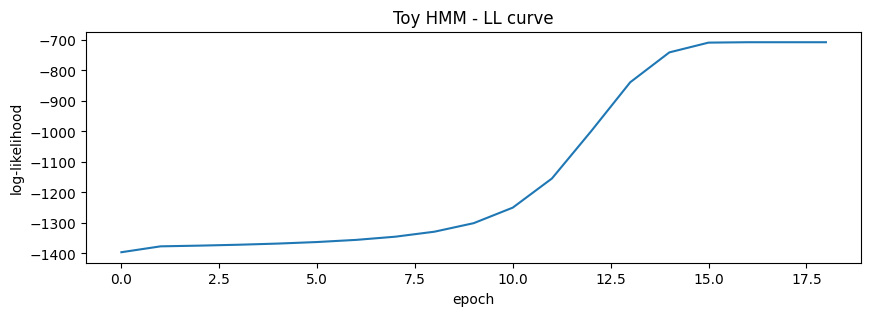

In [16]:
# check results
print("Learned A:")
print(toy_hmm.A)
print("\nLearned B:")
print(toy_hmm.B)

# figure out which state is which (labels can be swapped)
if toy_hmm.B[0, 1] < toy_hmm.B[1, 1]:
    s0, s1 = 0, 1
else:
    s0, s1 = 1, 0
print(f"\nstate {s0} -> zeros emitter: B = {toy_hmm.B[s0]} (expect ~[1, 0])")
print(f"state {s1} -> mixed emitter:  B = {toy_hmm.B[s1]} (expect ~[0.5, 0.5])")
print(f"A diag: [{toy_hmm.A[s0,s0]:.4f}, {toy_hmm.A[s1,s1]:.4f}] (expect ~0.999)")

# LL should be monotonically increasing
ll_diffs = np.diff(toy_ll)
print(f"\nLL monotonic: {np.all(ll_diffs >= -1e-6)}")

plt.figure(figsize=(10, 3))
plt.plot(toy_ll)
plt.title('Toy HMM - LL curve')
plt.xlabel('epoch'); plt.ylabel('log-likelihood')
plt.show()

## Training gesture HMMs

OK the HMM seems to work. Now let me train one model per gesture using the quantized training data. Starting with N=15 states and M=70 obs (from kmeans). Using left-right-cyclic since I didn't split the repeated gestures.

In [17]:
N = 15  # hidden states
gesture_models = {}
gesture_ll_curves = {}

for gname in gesture_prefixes.keys():
    print(f"\n=== Training {gname} ===")
    np.random.seed(42)
    hmm = HMM(n_states=N, n_obs=M, topology='left-right-cyclic')
    ll = hmm.train(training_obs[gname], max_iter=100, tol=1e-2)
    gesture_models[gname] = hmm
    gesture_ll_curves[gname] = ll
    print(f"  A diag range: [{np.diag(hmm.A).min():.3f}, {np.diag(hmm.A).max():.3f}]")
    print(f"  B row sums: min={hmm.B.sum(1).min():.6f}, max={hmm.B.sum(1).max():.6f}")


=== Training wave ===


  epoch 0: LL = -58359.77


  epoch 5: LL = -10571.43 (change: 530.5663)


  epoch 10: LL = -10504.17 (change: 3.5283)


  epoch 15: LL = -10493.02 (change: 1.5743)


...

  epoch 80: LL = -14580.50 (change: 0.7704)


  epoch 85: LL = -14574.04 (change: 0.8925)


  epoch 90: LL = -14546.73 (change: 23.5701)


  epoch 95: LL = -14103.93 (change: 1.1376)


  done: LL = -14102.24, 100 epochs
  A diag range: [0.807, 0.969]
  B row sums: min=1.000000, max=1.000000


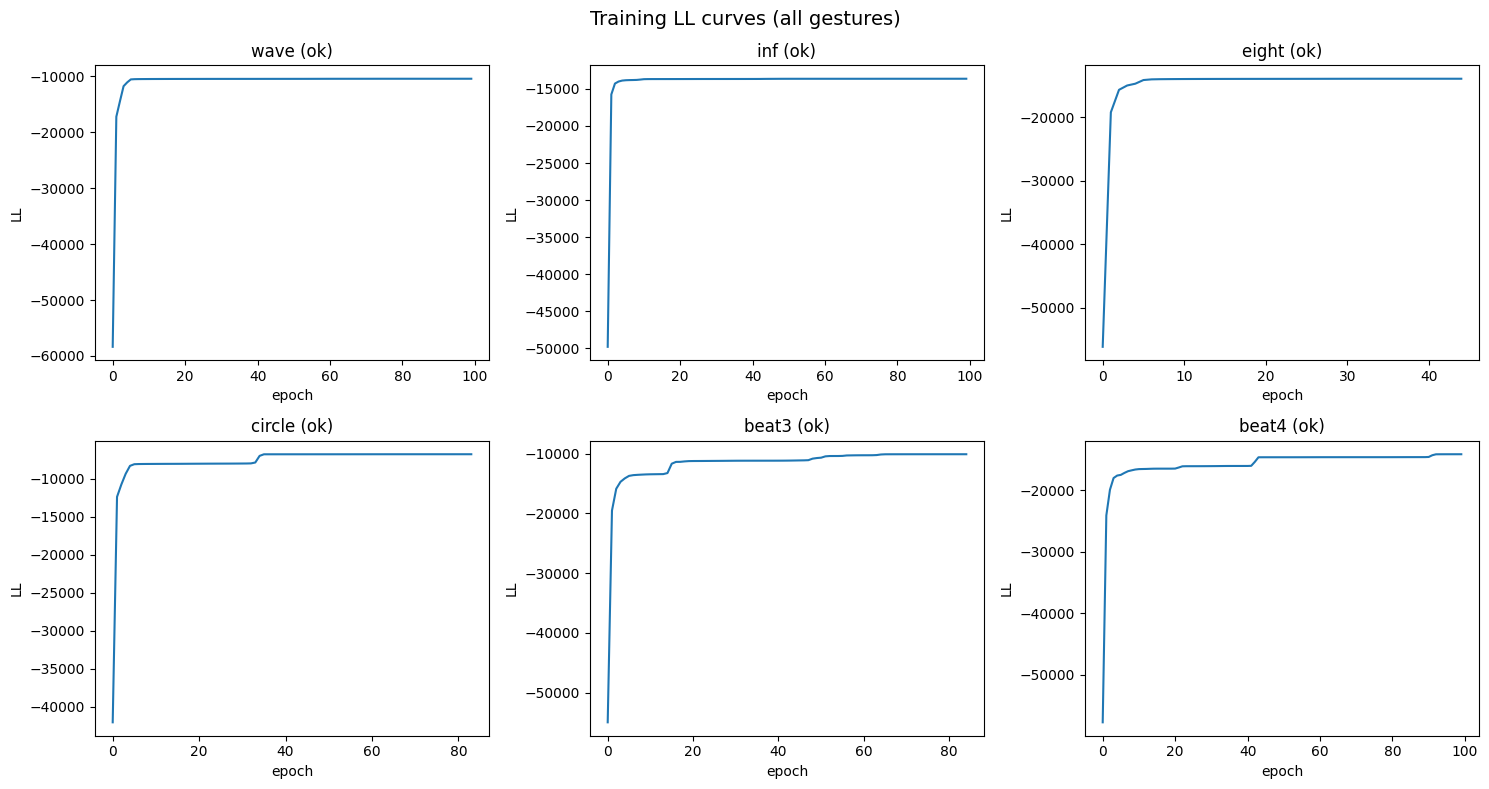

saved LL curves to docs/figures/


In [18]:
# plot LL curves for all gestures
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Training LL curves (all gestures)', fontsize=14)

for idx, gname in enumerate(gesture_prefixes.keys()):
    ax = axes[idx // 3][idx % 3]
    ax.plot(gesture_ll_curves[gname])
    ax.set_title(gname)
    ax.set_xlabel('epoch')
    ax.set_ylabel('LL')
    # check monotonicity
    diffs = np.diff(gesture_ll_curves[gname])
    is_mono = np.all(diffs >= -0.1)
    ax.set_title(f"{gname} ({'ok' if is_mono else 'BAD'})")

plt.tight_layout()
plt.savefig('docs/figures/ll_curves_all.png', dpi=100)
plt.show()
print("saved LL curves to docs/figures/")

In [19]:
# quick validation: classify the single gesture files (train set 2)
# each single file should have highest LL under its own gesture's model
print("=== Validation on single gesture files ===\n")
correct = 0
total = 0

for true_gesture in gesture_prefixes.keys():
    for seq in training_obs[true_gesture][-1:]:  # just the single file (last one)
        lls = {}
        for gname, model in gesture_models.items():
            lls[gname] = model.log_likelihood(seq)
        
        ranked = sorted(lls.items(), key=lambda x: -x[1])
        pred = ranked[0][0]
        top3 = [r[0] for r in ranked[:3]]
        
        is_correct = pred == true_gesture
        correct += int(is_correct)
        total += 1
        
        mark = "ok" if is_correct else "WRONG"
        print(f"  {true_gesture}: pred={pred} [{mark}]  top3={top3}")
        # print the actual LL values
        for gname, ll in ranked[:3]:
            print(f"    {gname}: {ll:.2f}")

print(f"\nAccuracy: {correct}/{total} = {correct/total:.1%}")

=== Validation on single gesture files ===

  wave: pred=wave [ok]  top3=['wave', 'beat3', 'inf']
    wave: -474.37
    beat3: -3674.98
    inf: -4266.72
  inf: pred=inf [ok]  top3=['inf', 'eight', 'beat3']
    inf: -591.93
    eight: -6821.91
    beat3: -8331.63
  eight: pred=eight [ok]  top3=['eight', 'inf', 'beat3']
    eight: -649.47
    inf: -4651.20
    beat3: -7753.93
  circle: pred=circle [ok]  top3=['circle', 'beat4', 'beat3']
    circle: -330.76
    beat4: -4088.55
    beat3: -5324.32


  beat3: pred=beat3 [ok]  top3=['beat3', 'beat4', 'wave']
    beat3: -440.64
    beat4: -622.83
    wave: -7234.48
  beat4: pred=beat4 [ok]  top3=['beat4', 'beat3', 'inf']
    beat4: -587.80
    beat3: -1357.83
    inf: -6733.56

Accuracy: 6/6 = 100.0%


In [20]:
# save trained models
for gname, model in gesture_models.items():
    model_data = {
        'A': model.A, 'B': model.B, 'pi': model.pi,
        'N': model.N, 'M': model.M,
        'topology': model.topology
    }
    fname = f'models/{gname}_hmm.pkl'
    with open(fname, 'wb') as f:
        pickle.dump(model_data, f)
    print(f"saved {fname}")

print("all models saved")

saved models/wave_hmm.pkl
saved models/inf_hmm.pkl
saved models/eight_hmm.pkl
saved models/circle_hmm.pkl
saved models/beat3_hmm.pkl
saved models/beat4_hmm.pkl
all models saved
